# Imaging, part 4: a ring around a binary star

Images rarely stand alone. The scenes interferometers observe often mix unresolved sources, such as stars or companions, with resolved emission, such as discs or envelopes. virgil composes the two:
- a `System` can hold analytic components, like `PointSource` stars, alongside an `Image`;
- all the parameters are fitted together.

**The rule of thumb is that unresolved things are analytic, and resolved emission goes in the pixels.**

This tutorial shows why that rule matters. The scene is a post-AGB-like system: a binary star inside an inclined, lopsided ring of dust. It is observed at the VLTI in H band, like PIONIER. The image is a Gaussian-process field as in part 3. The steps are:
1. Fit with one star. The companion is not in the model, so the image has to fake it with a knot of bright pixels.
2. Use that knot to locate the companion, then fit the binary and the image together.
3. Compare the two fits, which match the data almost equally well, and see how the evidence tells them apart.

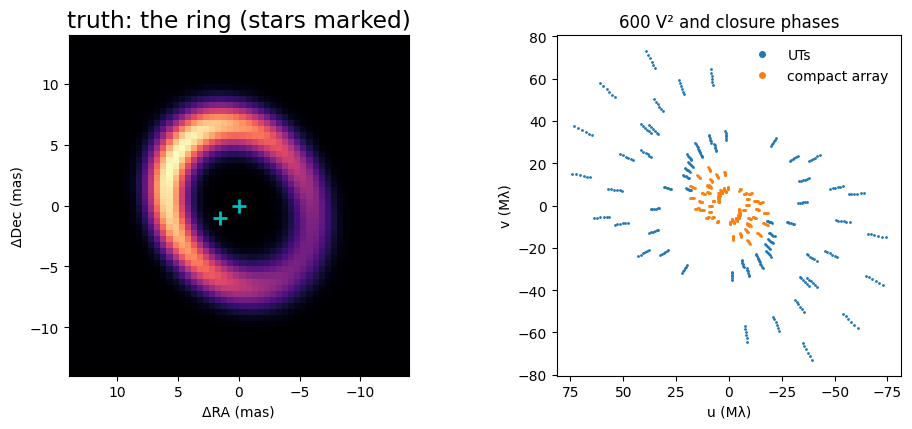

beam 4.4 × 2.5 mas; interferometric field of view 42 mas


In [1]:
import sys
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as onp
import numpyro.distributions as dist

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from virgil.coverage import VLTI_UTS, vlti_oidata
from virgil.fields import GaussianField
from virgil.fitting import fit
from virgil.imaging import beam, field_of_view, image_priors, log_evidence
from virgil.models import Image, ModulatedGaussianRim, PointSource, System, circular_support
from virgil.plotting import plot_model, plot_residual_map

# Two array configurations, as PIONIER uses: the four UTs, and a compact
# array a quarter of their size (a stand-in for the short AT baselines).
H_band = onp.linspace(1.55e-6, 1.75e-6, 6)
configurations = [vlti_oidata(stations=s, wavelengths_m=H_band, sigma_v2=0.01, sigma_cp_deg=0.5) for s in (VLTI_UTS, 0.25 * VLTI_UTS)]

# The truth: an 8% companion 1.8 mas from the primary, inside a 14 mas ring.
ring = ModulatedGaussianRim(diam=14.0, fwhm=3.0, inc=35.0, pa=30.0, az_amps=(0.5,), az_pas=(60.0,), flux=0.35)
truth = System(primary=PointSource(), secondary=PointSource(flux=0.08, dra=1.5, ddec=-1.0), ring=ring)
data = [d.with_model(truth, key=jax.random.PRNGKey(k)) for k, d in enumerate(configurations)]
resolution = beam(data)

npix, scale = 56, 0.5
fov = npix * scale
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
plot_model(ring, fov_mas=fov, npix=npix, ax=axes[0], title="truth: the ring (stars marked)")
axes[0].plot([0.0, 1.5], [0.0, -1.0], "c+", ms=10, mew=2, ls="none")
for d, label in zip(data, ("UTs", "compact array")):
    u, v = d.u / d.wavel / 1e6, d.v / d.wavel / 1e6
    axes[1].plot(jnp.concatenate([u, -u]).ravel(), jnp.concatenate([v, -v]).ravel(), ".", ms=2, label=label)
axes[1].set(xlabel="u (Mλ)", ylabel="v (Mλ)", aspect="equal", title=f"{sum(d.vis.size + d.phi.size for d in data)} V² and closure phases")
axes[1].invert_xaxis()
axes[1].legend(frameon=False, markerscale=4)
plt.tight_layout()
plt.show()
print(f"beam {resolution.major_mas:.1f} × {resolution.minor_mas:.1f} mas; interferometric field of view {field_of_view(data):.0f} mas")

## One star, and an image

The first model is the usual star-plus-image `System`:
- one `PointSource` at the origin;
- an `Image` whose log-brightness is a `GaussianField` about a broad ring template;
- a hole of half a beam under the star.

σ and ℓ are fixed here at values chosen from the evidence; part 3 shows how. The image's flux is fitted along with its pixels.

In [2]:
hole = circular_support(npix, scale, fov, 0.5 * resolution.minor_mas)
ring_template = onp.asarray(ModulatedGaussianRim(diam=14.0, fwhm=4.0, inc=30.0, pa=0.0).render(npix, fov))


def gp_image(flux=0.3):
    field = GaussianField(onp.zeros((npix, npix)), sigma=2.0, length_mas=1.5, mean=ring_template)
    return Image(field, scale, support=hole, flux=flux)


single = System(primary=PointSource(), env=gp_image())
single_fit = fit(single, image_priors(single) | {"env.flux": dist.Uniform(0.0, 2.0)}, data)
print(f"one star: converged {single_fit.info['converged']}, chi2 per point {single_fit.info['chi2_red']:.3f}, image flux {float(single_fit.values['env.flux']):.3f} (ring truth 0.35)")

one star: converged True, chi2 per point 0.938, image flux 0.443 (ring truth 0.35)


## Finding the companion

The companion is unresolved but not at the origin, so its signature is real closure phase. With no companion in the model, the image reproduces that signal with a compact knot of bright pixels. The knot also says where the companion is: its brightest pixel gives a starting position. The binary model then adds a second `PointSource`, with its flux and offset free, and fits it together with the image.

In [3]:
image = onp.asarray(single_fit.model.env.render(npix, fov))
row, col = onp.unravel_index(onp.argmax(image), image.shape)
centres = (onp.arange(npix)[::-1] - (npix - 1) / 2) * scale  # East is left
knot = (float(centres[col]), float(centres[row]))

binary = System(primary=PointSource(), secondary=PointSource(flux=0.05, dra=knot[0], ddec=knot[1]), env=gp_image())
priors = image_priors(binary) | {
    "env.flux": dist.Uniform(0.0, 2.0),
    "secondary.flux": dist.Uniform(0.0, 1.0),
    "secondary.dra": dist.Uniform(-5.0, 5.0),
    "secondary.ddec": dist.Uniform(-5.0, 5.0),
}
binary_fit = fit(binary, priors, data)
v = binary_fit.values
print(f"knot at ({knot[0]:.2f}, {knot[1]:.2f}) mas")
print(f"binary: converged {binary_fit.info['converged']}, chi2 per point {binary_fit.info['chi2_red']:.3f}")
print(f"companion {float(v['secondary.flux']):.3f} at ({float(v['secondary.dra']):.2f}, {float(v['secondary.ddec']):.2f}) mas (truth 0.080 at (1.50, -1.00)); image flux {float(v['env.flux']):.3f} (truth 0.35)")

knot at (1.25, -0.75) mas
binary: converged True, chi2 per point 0.929
companion 0.084 at (1.42, -0.96) mas (truth 0.080 at (1.50, -1.00)); image flux 0.353 (truth 0.35)


## One star against two

The two images are shown on a colour scale saturated at the brightest 0.5% of pixels, with the beam shaded and the fitted stars marked. Below them are their signed differences from the true ring, on one colour scale; these are MAP images, so the differences are not z-scores.

With one star, the companion's light becomes a knot next to the centre, and the ring is distorted around it. With the binary modelled, the ring is clean, and the companion's flux and position are measured directly.

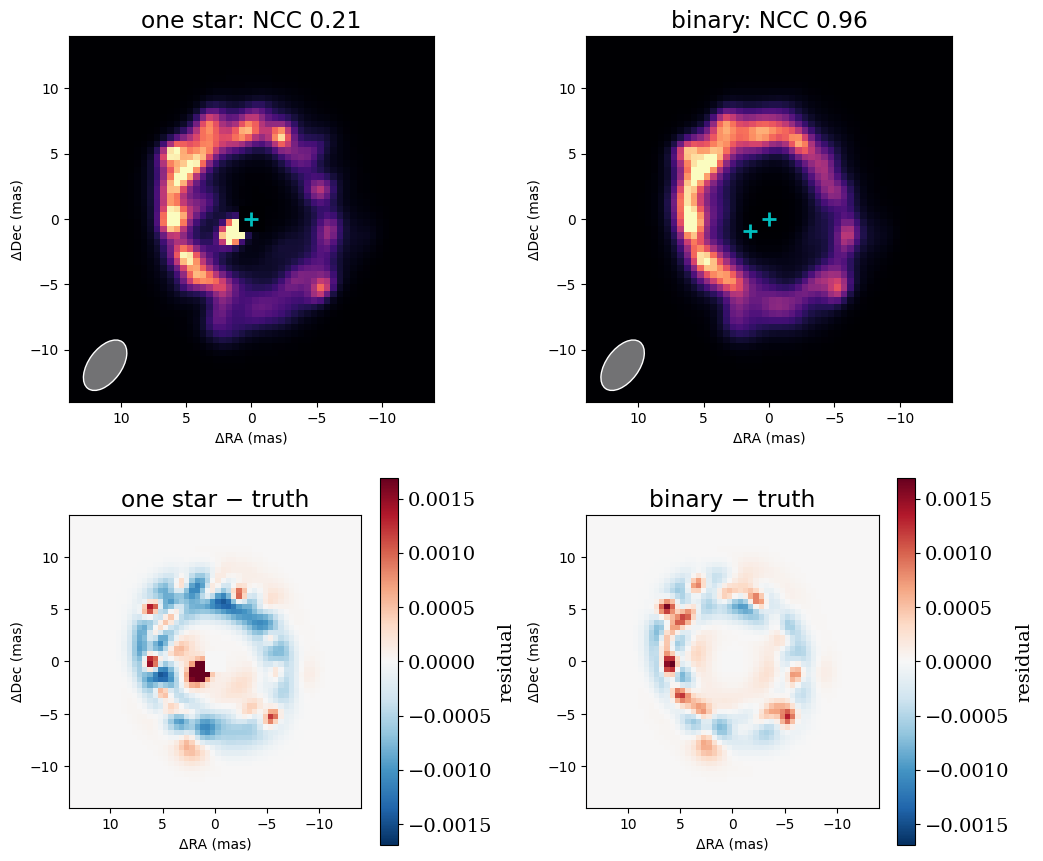

In [4]:
def ncc(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(jnp.sum(a * b) / jnp.sqrt(jnp.sum(a * a) * jnp.sum(b * b)))


truth_ring = ring.render(npix, fov)
fig, axes = plt.subplots(2, 2, figsize=(10.5, 9))
for column, (name, r) in enumerate((("one star", single_fit), ("binary", binary_fit))):
    model = r.model
    plot_model(model.env, fov_mas=fov, npix=npix, ax=axes[0, column], title=f"{name}: NCC {ncc(model.env.render(npix, fov), truth_ring):.2f}", saturate=0.995, beam=resolution)
    stars = [(0.0, 0.0)] + ([(float(model.secondary.dra), float(model.secondary.ddec))] if "secondary" in model.names else [])
    axes[0, column].plot(*zip(*stars), "c+", ms=10, mew=2, ls="none")
    plot_residual_map(model.env.render(npix, fov) - truth_ring, fov_mas=fov, ax=axes[1, column], title=f"{name} − truth")
# One colour scale for both residual maps, set by the binary fit: the
# one-star knot saturates it.
limit = float(jnp.abs(binary_fit.model.env.render(npix, fov) - truth_ring).max())
for ax in axes[1]:
    ax.images[0].set_clim(-limit, limit)
plt.tight_layout()
plt.show()

## Which model do the data prefer?

χ² cannot tell the two models apart: an image is flexible enough to absorb an unresolved companion, so both fit the data about equally well. The prior can. A knot of bright pixels is improbable under a smooth GP prior, because it needs large latents, whereas a point source costs only three parameters.

The evidence weighs both effects. `log_evidence` computes it for the image, with the other parameters, here the stars, held at their best-fit values. That leaves out the Occam penalty for the companion's three extra parameters, a few units of log evidence. Differences much larger than that are decisive.

In [5]:
for name, r in (("one star", single_fit), ("binary", binary_fit)):
    print(f"{name:9s}: chi2 {r.info['chi2_red'] * sum(r.info['ndata']):8.1f}, |z|² {float(jnp.sum(r.values['env.log_brightness.latent'] ** 2)):7.1f}, log evidence {log_evidence(r.model, data):8.1f}")

one star : chi2    506.6, |z|²    67.4, log evidence   -421.8


binary   : chi2    501.9, |z|²    19.4, log evidence   -388.9


## Summary

When an image sits next to analytic sources, what is analytic and what is in the pixels matters:
- **What goes wrong.** An unresolved companion left out of the model is absorbed by the image as a knot, which distorts the extended emission around it.
- **The fix.** Composing the scene as a `System` of `PointSource`s and an `Image` puts the companion where it belongs. The knot itself gives its starting position, and the fit measures its flux and offset alongside the ring.
- **Choosing between models.** χ² barely changes between the two, so the image's prior, through the evidence, is what prefers the right model.

The same composition works with any analytic component: disks, rims, resolved backgrounds and spectra (`virgil.spectra`). It works for real data too: the SPARCO-style analyses of PIONIER data in the companion notebooks follow this pattern.

Part 5 goes beyond the single MAP image, and samples the posterior to map each pixel's uncertainty.